# Pooled Good School DiD Notebook (0 -> 1 good schools)

This notebook builds the pooled good-school sample, checks baseline balance and raw trends, estimates the main pooled DiD specification, and keeps older SDID / clustering work as archived reference.


In [196]:
import numpy as np
import numpy as np
import pandas as pd

school_margin_df = pd.read_csv("../data/processed/final_resale_data_with_names.csv")
school_margin_df['Date'] = pd.to_datetime(school_margin_df['Date'])

In [80]:
import pandas as pd

def add_categorical_dummies(df, categorical_cols):
    dummies = pd.get_dummies(
        df[categorical_cols].astype('category'),
        prefix=categorical_cols,
        drop_first=True,
        dtype=float
    )
    out = pd.concat(
        [df.reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1
    )
    return out, dummies.columns.tolist()

def clean_label(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r'[^A-Za-z0-9]+', '_', regex=True)
        .str.strip('_')
    )

def bucket_count_level(series):
    s = pd.to_numeric(series, errors='coerce')
    out = pd.Series(pd.NA, index=series.index, dtype='object')
    out.loc[s == 0] = '0'
    out.loc[s == 1] = '1'
    out.loc[s >= 2] = '2plus'
    return out


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_monthly_log_price_and_gap(
    df,
    title,
    date_col='Date',
    price_col='resale_price',
    treated_col='treated',
    policy_start='2021-10-01',
):
    plot_df = df.copy()
    plot_df['year_month'] = plot_df[date_col].dt.to_period('M').astype(str)
    plot_df['log_price'] = np.log(plot_df[price_col])

    monthly = (
        plot_df
        .groupby(['year_month', treated_col], as_index=False)['log_price']
        .mean()
        .sort_values('year_month')
    )

    treated_ts = monthly[monthly[treated_col] == 1].copy()
    control_ts = monthly[monthly[treated_col] == 0].copy()

    months = sorted(monthly['year_month'].unique())
    xpos = np.arange(len(months))

    treated_y = treated_ts.set_index('year_month').reindex(months)['log_price']
    control_y = control_ts.set_index('year_month').reindex(months)['log_price']
    gap = treated_y - control_y

    boundary = None
    if policy_start[:7] in months:
        boundary = months.index(policy_start[:7]) - 0.5

    # Plot 1: levels
    plt.figure(figsize=(12, 5))
    plt.plot(xpos, control_y, marker='o', linewidth=2, label='Control')
    plt.plot(xpos, treated_y, marker='o', linewidth=2, label='Treated')

    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, months, rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Mean log resale price')
    plt.title(f'{title}\nMonthly log-price trends')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: treated - control gap
    plt.figure(figsize=(12, 4))
    plt.plot(xpos, gap, marker='o', linewidth=2, color='darkgreen')

    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, months, rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Treated - Control log price')
    plt.title(f'{title}\nMonthly treated-control gap')
    if boundary is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()


## Build Pooled Analysis Sample

Define the pre/post windows, construct school-count features, and filter to the pooled 0-to-1 good-school comparison sample.


In [199]:
pre_start  = pd.Timestamp('2018-09-01')
pre_end    = pd.Timestamp('2021-08-31')
post_start = pd.Timestamp('2021-10-01')
post_end   = pd.Timestamp('2023-03-31')

margin_new = school_margin_df[
    ((school_margin_df['Date'] >= pre_start) & (school_margin_df['Date'] <= pre_end)) |
    ((school_margin_df['Date'] >= post_start) & (school_margin_df['Date'] <= post_end))
].copy()

margin_new['period'] = np.where(margin_new['Date'] >= post_start, 'post', 'pre')
margin_new['post'] = (margin_new['period'] == 'post').astype(int)

margin_new['pre_num_good_schools_0_1km']  = margin_new['num_good_schools_0_1km_xy']
margin_new['post_num_good_schools_0_1km'] = margin_new['num_good_schools_0_1km_polygon']
margin_new['pre_num_good_schools_1_2km']  = margin_new['num_good_schools_1_2km_xy']
margin_new['post_num_good_schools_1_2km'] = margin_new['num_good_schools_1_2km_polygon']
margin_new['pre_good_school_names_0_1km'] = margin_new['good_school_names_0_1km_xy']
margin_new['pre_good_school_names_1_2km'] = margin_new['good_school_names_1_2km_xy']
margin_new['post_good_school_names_0_1km'] = margin_new['good_school_names_0_1km_polygon']
margin_new['post_good_school_names_1_2km'] = margin_new['good_school_names_1_2km_polygon']
margin_new['pre_num_good_schools_0_1km_bin'] = bucket_count_level(margin_new['pre_num_good_schools_0_1km'])
margin_new['pre_num_good_schools_1_2km_bin'] = bucket_count_level(margin_new['pre_num_good_schools_1_2km'])

margin_new['pre_num_good_schools_0_2km']  = margin_new['pre_num_good_schools_0_1km'] + margin_new['pre_num_good_schools_1_2km']
margin_new['post_num_good_schools_0_2km'] = margin_new['post_num_good_schools_0_1km'] + margin_new['post_num_good_schools_1_2km']

margin_new['pre_num_schools_0_1km']  = margin_new['num_schools_0_1km_xy']
margin_new['post_num_schools_0_1km'] = margin_new['num_schools_0_1km_polygon']
margin_new['pre_num_schools_1_2km']  = margin_new['num_schools_1_2km_xy']
margin_new['post_num_schools_1_2km'] = margin_new['num_schools_1_2km_polygon']

margin_new['pre_num_schools_0_2km']  = margin_new['pre_num_schools_0_1km'] + margin_new['pre_num_schools_1_2km']
margin_new['post_num_schools_0_2km'] = margin_new['post_num_schools_0_1km'] + margin_new['post_num_schools_1_2km']

margin_new['pre_num_normal_schools_0_1km'] = (
    margin_new['pre_num_schools_0_1km'] - margin_new['pre_num_good_schools_0_1km']
)
margin_new['post_num_normal_schools_0_1km'] = (
    margin_new['post_num_schools_0_1km'] - margin_new['post_num_good_schools_0_1km']
)
margin_new['pre_num_normal_schools_1_2km'] = (
    margin_new['pre_num_schools_1_2km'] - margin_new['pre_num_good_schools_1_2km']
)
margin_new['post_num_normal_schools_1_2km'] = (
    margin_new['post_num_schools_1_2km'] - margin_new['post_num_good_schools_1_2km']
)
margin_new['pre_num_normal_schools_0_2km'] = (
    margin_new['pre_num_schools_0_2km'] - margin_new['pre_num_good_schools_0_2km']
)
margin_new['post_num_normal_schools_0_2km'] = (
    margin_new['post_num_schools_0_2km'] - margin_new['post_num_good_schools_0_2km']
)

margin_new['delta_good_schools_0_1km'] = margin_new['post_num_good_schools_0_1km'] - margin_new['pre_num_good_schools_0_1km']

did_01x_new = margin_new[
    (margin_new['delta_good_schools_0_1km'].isin([0, 1])) &  # ensure treated units only have 0->1 change in good schools within 1km
    (margin_new['pre_num_normal_schools_0_1km'] == margin_new['post_num_normal_schools_0_1km']) &  # ensure no change in number of normal schools within 1km
    (margin_new['pre_num_normal_schools_1_2km'] == margin_new['post_num_normal_schools_1_2km']) # ensure no change in number of normal schools within 1-2km

].copy()

did_01x_new['treated'] = (did_01x_new['delta_good_schools_0_1km'] == 1).astype(int)
did_01x_new['year_quarter'] = did_01x_new['Date'].dt.to_period('Q').astype(str)
did_01x_new['log_price'] = np.log(did_01x_new['resale_price'])
did_01x_new['flat_type_clean'] = clean_label(did_01x_new['flat_type'])

print("Sample size by treated / period:")
print(did_01x_new.groupby(['treated', 'period']).size())


Sample size by treated / period:
treated  period
0        post      15930
         pre       27284
1        post        846
         pre        1316
dtype: int64


## Baseline Diagnostics And Raw Trends

Check observable balance, inspect the pooled treated/control gap, and review the analysis columns before estimating the main model.


In [93]:
# Check if treated and control differ systematically on observables
balance_cols = [
    'floor_area_sqm', 'remaining_lease',
    'num_unique_mrt_lines', 'num_nearby_malls',
    'pre_num_good_schools_1_2km', 'pre_num_normal_schools_0_1km'
]

print(
    did_01x_new.groupby('treated')[balance_cols]
    .mean()
    .T
    .assign(diff=lambda d: d[1] - d[0])
)

treated                                0           1       diff
floor_area_sqm                 96.025577   92.109621  -3.915957
remaining_lease               879.483061  823.506938 -55.976123
num_unique_mrt_lines            1.170014    1.227105   0.057090
num_nearby_malls                1.469663    1.334875  -0.134787
pre_num_good_schools_1_2km      0.638196    1.660500   1.022304
pre_num_normal_schools_0_1km    2.687324    2.343663  -0.343660


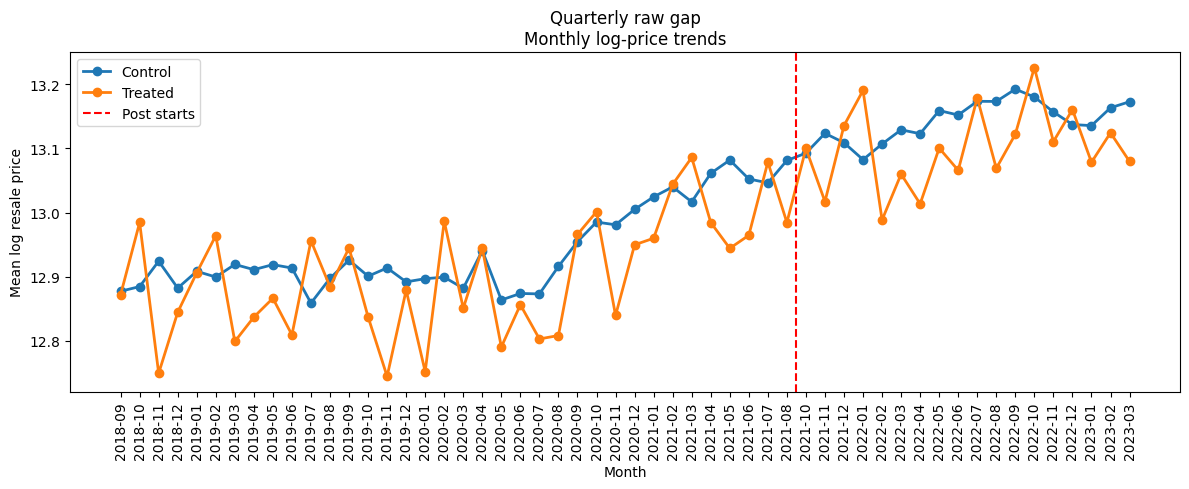

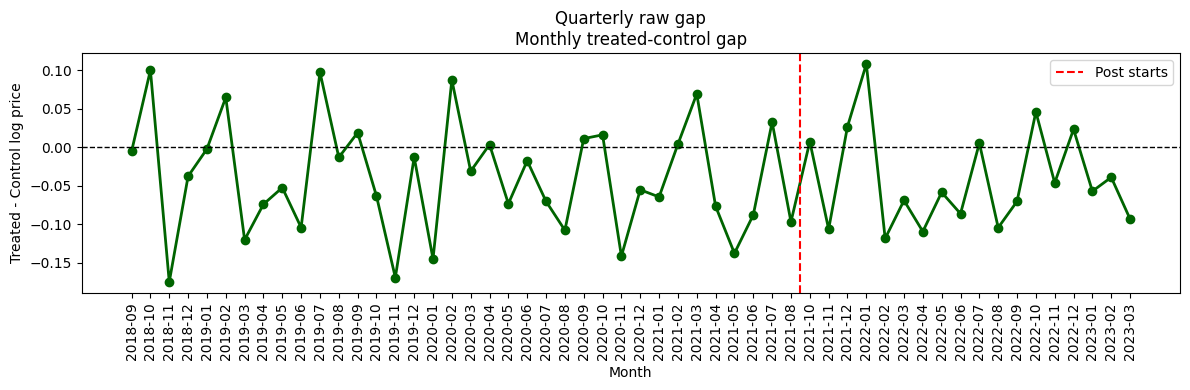

In [95]:
did_01x_new['year_quarter'] = did_01x_new['Date'].dt.to_period('Q').astype(str)
plot_monthly_log_price_and_gap(
    did_01x_new[
        (did_01x_new['treated'] == 1) |
        (
            (did_01x_new['treated'] == 0) &
            (did_01x_new['pre_num_good_schools_1_2km'] > 0) &
            (did_01x_new['pre_num_good_schools_0_1km'] == did_01x_new['post_num_good_schools_0_1km'])
        )
    ],
    title='Quarterly raw gap',
    date_col='Date',   # but aggregate by quarter not month
)

In [363]:
did_01x_new.columns

Index(['month', 'town', 'flat_type', 'storey_range', 'floor_area_sqm',
       'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease',
       'address', 'year', 'latitude', 'longitude', 'geometry', 'Date',
       'num_nearby_malls', 'num_nearby_mrt', 'num_unique_mrt_lines',
       'num_schools_0_1km_polygon', 'num_schools_0_1km_xy',
       'num_schools_1_2km_polygon', 'num_schools_1_2km_xy',
       'num_good_schools_0_1km_polygon', 'num_good_schools_0_1km_xy',
       'num_good_schools_1_2km_polygon', 'num_good_schools_1_2km_xy', 'period',
       'post', 'pre_num_good_schools_0_1km', 'post_num_good_schools_0_1km',
       'pre_num_good_schools_1_2km', 'post_num_good_schools_1_2km',
       'pre_num_good_schools_0_2km', 'post_num_good_schools_0_2km',
       'pre_num_schools_0_1km', 'post_num_schools_0_1km',
       'pre_num_schools_1_2km', 'post_num_schools_1_2km',
       'pre_num_schools_0_2km', 'post_num_schools_0_2km',
       'pre_num_normal_schools_0_1km', 'post_num_norma

## Main Pooled DiD With Covariates (No Clustering)

This is the primary pooled specification used for the notebook results.


In [ ]:
import numpy as np
import geopandas as gpd
import statsmodels.formula.api as smf
from shapely import wkt

# -----------------------------------------------------------------------------
# Plain DiD with local matched controls
# Controls are assigned to their nearest treated flat within the same stratum
# and kept only if they are within 200m of that treated flat.
# -----------------------------------------------------------------------------

control_radius_m = 200

did_df_nc = did_01x_new.copy()

did_df_nc = did_df_nc[
    (did_df_nc['treated'] == 1) |
    (
        (did_df_nc['treated'] == 0) &
        (did_df_nc['pre_num_good_schools_1_2km'] > 0)
    )
].copy()

did_df_nc['log_price'] = np.log(did_df_nc['resale_price'])
did_df_nc['year_quarter'] = did_df_nc['Date'].dt.to_period('Q').astype(str)
did_df_nc['flat_type_clean'] = clean_label(did_df_nc['flat_type'])
did_df_nc['stratum_id'] = (
    'ft_' + did_df_nc['flat_type_clean']
)

did_df_nc['geometry'] = did_df_nc['geometry'].apply(
    lambda g: wkt.loads(g) if isinstance(g, str) else g
)
did_gdf_nc = gpd.GeoDataFrame(did_df_nc, geometry='geometry', crs='EPSG:3414')

local_parts = []
match_summary = []

for stratum_id in sorted(did_gdf_nc['stratum_id'].dropna().unique()):
    gdf_s = did_gdf_nc[did_gdf_nc['stratum_id'] == stratum_id].copy()

    treated_s = gdf_s[gdf_s['treated'] == 1].copy()
    control_s = gdf_s[gdf_s['treated'] == 0].copy()

    if treated_s.empty or control_s.empty:
        continue

    treated_s['x_coord'] = treated_s.geometry.x
    treated_s['y_coord'] = treated_s.geometry.y
    control_s['x_coord'] = control_s.geometry.x
    control_s['y_coord'] = control_s.geometry.y

    treated_sites = treated_s[['x_coord', 'y_coord', 'geometry']].drop_duplicates(
        subset=['x_coord', 'y_coord']
    ).reset_index(drop=True)
    treated_sites['treated_site_id'] = range(len(treated_sites))
    treated_sites = gpd.GeoDataFrame(treated_sites, geometry='geometry', crs=gdf_s.crs)

    treated_s = treated_s.merge(
        treated_sites[['x_coord', 'y_coord', 'treated_site_id']],
        on=['x_coord', 'y_coord'],
        how='left'
    )

    control_join = gpd.sjoin_nearest(
        control_s,
        treated_sites[['treated_site_id', 'geometry']],
        how='left',
        distance_col='dist_to_treated'
    )

    control_keep = control_join[
        control_join['dist_to_treated'] <= control_radius_m
    ].copy()

    if control_keep.empty:
        continue

    matched_site_ids = control_keep['treated_site_id'].dropna().unique()
    treated_keep = treated_s[treated_s['treated_site_id'].isin(matched_site_ids)].copy()

    if treated_keep.empty:
        continue

    control_keep = control_keep.drop(columns=['index_right'], errors='ignore')

    local_parts.append(treated_keep)
    local_parts.append(control_keep)
    match_summary.append({
        'stratum_id': stratum_id,
        'treated_obs': len(treated_keep),
        'control_obs': len(control_keep),
        'matched_treated_sites': len(matched_site_ids)
    })

if not local_parts:
    raise ValueError('No matched treated-control sample found within 200m.')

did_df_nc = pd.concat(local_parts, ignore_index=True)

print('Matched sample size by treated / period:')
print(did_df_nc.groupby(['treated', 'period']).size())

match_summary_df = pd.DataFrame(match_summary)
print('\nMatched strata retained:', match_summary_df['stratum_id'].nunique())
print('Matched treated sites:', int(match_summary_df['matched_treated_sites'].sum()))

did_model_nc = smf.ols(
    """
    log_price ~ treated * post
    + C(year_quarter)
    + C(stratum_id)
    + floor_area_sqm
    + remaining_lease
    + num_nearby_mrt
    + num_unique_mrt_lines
    + num_nearby_malls
    + C(flat_model)
    + C(storey_range)
    """,
    data=did_df_nc
).fit(
    cov_type='cluster',
    cov_kwds={'groups': did_df_nc['stratum_id']}
)

pre_df_nc = did_df_nc[did_df_nc['post'] == 0].copy()
pretrend_ref_q = sorted(pre_df_nc['year_quarter'].unique())[-1]

pretrend_model_nc = smf.ols(
    f"""
    log_price ~ treated
    + C(year_quarter, Treatment(reference='{pretrend_ref_q}'))
    + treated:C(year_quarter, Treatment(reference='{pretrend_ref_q}'))
    + C(stratum_id)
    + floor_area_sqm
    + remaining_lease
    + num_nearby_mrt
    + num_unique_mrt_lines
    + num_nearby_malls
    + C(flat_model)
    + C(storey_range)
    """,
    data=pre_df_nc
).fit(
    cov_type='cluster',
    cov_kwds={'groups': pre_df_nc['stratum_id']}
)

pretrend_terms_nc = [
    term for term in pretrend_model_nc.params.index
    if 'treated:C(year_quarter' in term
]

if pretrend_terms_nc:
    restriction_nc = ', '.join(f'{term} = 0' for term in pretrend_terms_nc)
    pretrend_f_test_nc = pretrend_model_nc.f_test(restriction_nc)
    print('\nPre-trend joint F-test (matched 200m sample):')
    print(f'F-stat: {float(pretrend_f_test_nc.fvalue):.4f}')
    print(f'p-value: {float(pretrend_f_test_nc.pvalue):.4f}')
    print(f'Reference pre-quarter: {pretrend_ref_q}')
else:
    print('\nPre-trend joint F-test skipped: no treated-by-quarter pre terms found.')

print('\nNon-clustered DiD ATT (treated:post):')
print(did_model_nc.params['treated:post'])
print(did_model_nc.bse['treated:post'])
print(did_model_nc.pvalues['treated:post'])
print(did_model_nc.summary())


## Archived SDID workflow (unused)

The non-clustered SDID path below is archived only for reference.
The pooled main results for this notebook come from the plain DiD section above.


## Clustering logic (unused)

The pooled main specification is the standard DiD workflow above.
This clustering-based SDID path is kept only as archival / reference material and is not used for the pooled results.


### Archived Clustering Sample Setup And Inspection

Build the clustering-based local sample and inspect cluster composition, balance, pre-gap behavior, and retained SDID units.


In [74]:
did_01x_new[did_01x_new['delta_good_schools_0_1km']==0]['pre_num_good_schools_1_2km'].value_counts()

pre_num_good_schools_1_2km
0    23966
1    12662
2     4948
3     1531
4      107
Name: count, dtype: int64

In [10]:
def trim_periods_before_balancing(
    panel_df,
    unit_col='unit_id',
    time_col='year_quarter',
    treated_col='treated',
    min_treated_units_per_period=1,
    min_control_units_per_period=1,
):
    period_support = (
        panel_df
        .groupby([time_col, treated_col])[unit_col]
        .nunique()
        .unstack(fill_value=0)
        .rename(columns={0: 'control_units', 1: 'treated_units'})
        .sort_index()
    )

    for col in ['control_units', 'treated_units']:
        if col not in period_support.columns:
            period_support[col] = 0

    keep_periods = period_support.index[
        (period_support['treated_units'] >= min_treated_units_per_period) &
        (period_support['control_units'] >= min_control_units_per_period)
    ].tolist()

    trimmed = panel_df[panel_df[time_col].isin(keep_periods)].copy()

    return {
        'panel_df': trimmed,
        'period_support': period_support.reset_index(),
        'keep_periods': keep_periods,
    }

In [76]:
from sklearn.cluster import DBSCAN
from diff_diff import SyntheticDiD
from diff_diff.prep import balance_panel
from shapely import wkt
import geopandas as gpd
import pandas as pd
import numpy as np

def build_clustered_sdid_objects(
    base_df,
    cluster_eps_m,
    control_radius_m,
    min_treated_obs=10,
    min_control_obs=1,
    min_treated_units_per_period=1,
    min_control_units_per_period=1,
    post_start='2021Q4',
):
    work_df = base_df.copy()

    work_df = work_df[
        (work_df['treated'] == 1) |
        (
            (work_df['treated'] == 0) &
            (work_df['pre_num_good_schools_1_2km'] > 0)
        )
    ].copy()

    work_df['geometry'] = work_df['geometry'].apply(
        lambda g: wkt.loads(g) if isinstance(g, str) else g
    )

    work_gdf = gpd.GeoDataFrame(
        work_df,
        geometry='geometry',
        crs='EPSG:3414'
    )
    work_gdf = work_gdf.to_crs('EPSG:3414')
    local_parts = []
    cluster_summary_rows = []

    treated_n = work_gdf[work_gdf['treated'] == 1].copy()
    control_n = work_gdf[work_gdf['treated'] == 0].copy()

    if not (treated_n.empty or control_n.empty):
        treated_sites = treated_n[['geometry']].copy()
        treated_sites['x_coord'] = treated_sites.geometry.x
        treated_sites['y_coord'] = treated_sites.geometry.y
        treated_sites = treated_sites.drop_duplicates(
            subset=['x_coord', 'y_coord']
        ).reset_index(drop=True)

        db = DBSCAN(eps=cluster_eps_m, min_samples=1)
        treated_sites['cluster_num'] = db.fit_predict(
            treated_sites[['x_coord', 'y_coord']]
        )
        treated_sites['local_group_id'] = (
            'cluster_' + treated_sites['cluster_num'].astype(str)
        )

        treated_sites = gpd.GeoDataFrame(
            treated_sites,
            geometry='geometry',
            crs=work_gdf.crs
        )

        cluster_polygons = treated_sites.dissolve(by='local_group_id', as_index=False)
        cluster_polygons['cluster_num'] = (
            cluster_polygons['local_group_id'].str.replace('cluster_', '', regex=False).astype(int)
        )
        cluster_polygons['geometry'] = cluster_polygons.geometry.convex_hull

        catchment_polygons = cluster_polygons.copy()
        catchment_polygons['geometry'] = catchment_polygons.geometry.buffer(control_radius_m)

        treated_labeled = treated_n.copy()
        treated_labeled['x_coord'] = treated_labeled.geometry.x
        treated_labeled['y_coord'] = treated_labeled.geometry.y
        treated_labeled = treated_labeled.merge(
            treated_sites[['x_coord', 'y_coord', 'local_group_id', 'cluster_num']],
            on=['x_coord', 'y_coord'],
            how='left'
        )

        control_n = control_n.copy()
        control_n['control_obs_id'] = np.arange(len(control_n))

        control_candidates_n = gpd.sjoin(
            control_n,
            catchment_polygons[['local_group_id', 'cluster_num', 'geometry']],
            how='inner',
            predicate='within'
        )

        if not control_candidates_n.empty:
            polygon_lookup = cluster_polygons[['local_group_id', 'geometry']].rename(
                columns={'geometry': 'cluster_polygon'}
            )
            control_candidates_n = control_candidates_n.merge(
                polygon_lookup,
                on='local_group_id',
                how='left'
            )
            control_candidates_n['dist_to_cluster_polygon'] = control_candidates_n.apply(
                lambda row: row.geometry.distance(row['cluster_polygon']),
                axis=1
            )
            control_keep_n = (
                control_candidates_n
                .sort_values(['control_obs_id', 'dist_to_cluster_polygon'])
                .drop_duplicates(subset=['control_obs_id'])
                .drop(columns=['index_right', 'control_obs_id', 'cluster_polygon'])
            )
        else:
            control_keep_n = control_candidates_n.copy()

        did_local_n = pd.concat([treated_labeled, control_keep_n], ignore_index=True)

        if not did_local_n.empty:
            cluster_counts_n = (
                did_local_n.groupby(['local_group_id', 'treated'])
                .size()
                .unstack(fill_value=0)
                .rename(columns={0: 'control_obs', 1: 'treated_obs'})
                .reset_index()
            )
            cluster_summary_rows.append(cluster_counts_n)
            local_parts.append(did_local_n)

    if len(local_parts) == 0:
        return {
            'did_local': pd.DataFrame(),
            'cluster_summary': pd.DataFrame(),
            'sdid_panel': pd.DataFrame(),
            'covariate_cols': [],
            'n_units_before_period_trim': 0,
            'n_units_pre_balance': 0,
            'post_periods': [],
            'period_support': pd.DataFrame(),
            'keep_periods': [],
        }

    did_local = pd.concat(local_parts, ignore_index=True)
    did_local['year_quarter'] = did_local['Date'].dt.to_period('Q').astype(str)
    did_local['log_price'] = np.log(did_local['resale_price'])

    cluster_summary = (
        pd.concat(cluster_summary_rows, ignore_index=True)
        if cluster_summary_rows else
        pd.DataFrame(columns=['local_group_id', 'control_obs', 'treated_obs'])
    )

    cluster_summary['both_arms'] = (
        (cluster_summary['treated_obs'] > 0) &
        (cluster_summary['control_obs'] > 0)
    )

    valid_groups = cluster_summary.loc[
        (cluster_summary['treated_obs'] >= min_treated_obs) &
        (cluster_summary['control_obs'] >= min_control_obs),
        'local_group_id'
    ]

    did_local = did_local[did_local['local_group_id'].isin(valid_groups)].copy()
    cluster_summary = cluster_summary[
        cluster_summary['local_group_id'].isin(valid_groups)
    ].copy()

    if did_local.empty or cluster_summary.empty:
        return {
            'did_local': did_local,
            'cluster_summary': cluster_summary,
            'sdid_panel': pd.DataFrame(),
            'covariate_cols': [],
            'n_units_before_period_trim': 0,
            'n_units_pre_balance': 0,
            'post_periods': [],
            'period_support': pd.DataFrame(),
            'keep_periods': [],
        }

    did_local, cat_dummy_cols = add_categorical_dummies(
        did_local,
        ['pre_num_good_schools_1_2km_bin', 'flat_model', 'storey_range']
    )

    covariate_cols = [
        'floor_area_sqm',
        'remaining_lease',
    ] + cat_dummy_cols

    did_local['unit_id'] = (
        did_local['local_group_id'].astype(str)
        + '_T' + did_local['treated'].astype(str)
        + '_g01_' + did_local['pre_num_good_schools_0_1km_bin'].astype(str)
        + '_ft_' + did_local['flat_type_clean']
    )

    unit_meta = did_local[['unit_id', 'treated']].drop_duplicates()

    agg_map = {
        'log_price': ('log_price', 'mean'),
        'floor_area_sqm': ('floor_area_sqm', 'mean'),
        'remaining_lease': ('remaining_lease', 'mean'),
    }
    agg_map.update({col: (col, 'mean') for col in cat_dummy_cols})

    sdid_panel = (
        did_local
        .groupby(['unit_id', 'year_quarter'], as_index=False)
        .agg(**agg_map)
        .merge(unit_meta, on='unit_id', how='left')
    )

    n_units_before_period_trim = sdid_panel['unit_id'].nunique()

    trim_out = trim_periods_before_balancing(
        sdid_panel,
        unit_col='unit_id',
        time_col='year_quarter',
        treated_col='treated',
        min_treated_units_per_period=min_treated_units_per_period,
        min_control_units_per_period=min_control_units_per_period,
    )
    sdid_panel = trim_out['panel_df']
    period_support = trim_out['period_support']
    keep_periods = trim_out['keep_periods']

    n_units_pre_balance = sdid_panel['unit_id'].nunique()

    if sdid_panel.empty or len(keep_periods) == 0:
        return {
            'did_local': did_local,
            'cluster_summary': cluster_summary,
            'sdid_panel': pd.DataFrame(),
            'covariate_cols': covariate_cols,
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'post_periods': [],
            'period_support': period_support,
            'keep_periods': keep_periods,
        }

    sdid_panel = balance_panel(
        sdid_panel,
        unit_column='unit_id',
        time_column='year_quarter',
        method='inner'
    )

    if sdid_panel.empty:
        return {
            'did_local': did_local,
            'cluster_summary': cluster_summary,
            'sdid_panel': sdid_panel,
            'covariate_cols': covariate_cols,
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'post_periods': [],
            'period_support': period_support,
            'keep_periods': keep_periods,
        }

    sdid_panel['treated'] = (
        sdid_panel.groupby('unit_id')['treated']
        .transform('max')
        .astype(int)
    )

    post_periods = sorted(
        sdid_panel.loc[sdid_panel['year_quarter'] >= post_start, 'year_quarter'].unique()
    )

    return {
        'did_local': did_local,
        'cluster_summary': cluster_summary,
        'sdid_panel': sdid_panel,
        'covariate_cols': covariate_cols,
        'n_units_before_period_trim': n_units_before_period_trim,
        'n_units_pre_balance': n_units_pre_balance,
        'post_periods': post_periods,
        'period_support': period_support,
        'keep_periods': keep_periods,
    }


In [209]:
cluster_eps_m=1400
control_radius_m=500

built = build_clustered_sdid_objects(
    base_df=did_01x_new,
    cluster_eps_m=cluster_eps_m,
    control_radius_m=control_radius_m,
    min_control_obs=13,
    min_treated_obs=10,
)

did_local = built['did_local']
cluster_summary = built['cluster_summary']
sdid_panel_pool = built['sdid_panel']
covariate_cols_pool = built['covariate_cols']
post_periods_pool = built['post_periods']

pre_means = (
    did_local[did_local['period'] == 'pre']
    .groupby(['local_group_id', 'treated'])['log_price']
    .mean()
    .unstack()
    .rename(columns={0: 'control_mean', 1: 'treated_mean'})
)
pre_means['gap'] = pre_means['treated_mean'] - pre_means['control_mean']

print(pre_means.sort_values('gap'))
print(f"\nClusters where treated < control pre-period: {(pre_means['gap'] < 0).sum()} / {len(pre_means)}")
print(f"Mean within-cluster gap: {pre_means['gap'].mean():.4f}")

treated         control_mean  treated_mean       gap
local_group_id                                      
cluster_13         13.329090     12.360847 -0.968244
cluster_1          12.813897     12.557005 -0.256892
cluster_18         13.044968     12.917426 -0.127541
cluster_6          12.860983     12.805646 -0.055337
cluster_3          12.978972     12.937540 -0.041432
cluster_12         12.799257     12.768032 -0.031226
cluster_8          12.798106     12.767534 -0.030572
cluster_16         12.643430     12.615778 -0.027652
cluster_5          12.868661     12.860153 -0.008509
cluster_15         12.837401     12.835189 -0.002212
cluster_9          13.077815     13.091572  0.013756
cluster_0          12.983985     13.004912  0.020927
cluster_2          13.008207     13.051095  0.042888
cluster_4          12.860121     12.921078  0.060957
cluster_10         13.058969     13.132867  0.073898
cluster_7          12.922683     13.095685  0.173002
cluster_17         12.812427     13.025599  0.

In [189]:
balance_cols = [
    'floor_area_sqm', 'remaining_lease',
    'num_unique_mrt_lines', 'num_nearby_malls',
    'pre_num_good_schools_1_2km', 'pre_num_normal_schools_0_1km'
]

balance = (
    did_local[did_local['period'] == 'pre']
    .groupby('treated')[balance_cols]
    .mean()
    .T
    .rename(columns={0: 'control', 1: 'treated'})
    .assign(diff=lambda d: d['treated'] - d['control'],
            pct_diff=lambda d: (d['treated'] - d['control']) / d['control'] * 100)
)
print(balance.round(3))

treated                       control  treated    diff  pct_diff
floor_area_sqm                 93.521   92.774  -0.748    -0.799
remaining_lease               847.243  822.403 -24.839    -2.932
num_unique_mrt_lines            1.156    1.182   0.025     2.172
num_nearby_malls                1.364    1.334  -0.030    -2.191
pre_num_good_schools_1_2km      1.456    1.669   0.214    14.687
pre_num_normal_schools_0_1km    2.719    2.472  -0.247    -9.080


In [190]:
quarterly_gap = (
    did_local
    .groupby(['local_group_id', 'year_quarter', 'treated'])['log_price']
    .mean()
    .unstack('treated')
    .rename(columns={0: 'control', 1: 'treated'})
    .assign(gap=lambda d: d['treated'] - d['control'])
    .reset_index()
)

# Pre vs post gap by cluster
print(
    quarterly_gap
    .assign(period=lambda d: d['year_quarter'].ge('2021Q4').map({True: 'post', False: 'pre'}))
    .groupby(['local_group_id', 'period'])['gap']
    .mean()
    .unstack()
    .assign(delta=lambda d: d['post'] - d['pre'])
    .sort_values('delta', ascending=False)
)

period              post       pre     delta
local_group_id                              
cluster_8       0.438358  0.254494  0.183864
cluster_3      -0.052920 -0.153656  0.100737
cluster_7       0.009510 -0.086123  0.095633
cluster_1      -0.143782 -0.190890  0.047108
cluster_2      -0.074351 -0.086047  0.011696
cluster_9       0.098251  0.088032  0.010218
cluster_5       0.020373  0.024902 -0.004529
cluster_6       0.020347  0.027389 -0.007043
cluster_10      0.020844  0.030254 -0.009411
cluster_4      -0.141316 -0.119479 -0.021837
cluster_0      -0.028590  0.024397 -0.052987


In [203]:
# Merge pre-period gap back onto cluster_summary
cluster_check = cluster_summary.merge(
    pre_means[['gap']].rename(columns={'gap': 'pre_period_gap'}),
    on='local_group_id',
    how='left'
)

print(
    cluster_check[['local_group_id', 'treated_obs', 'control_obs', 'pre_period_gap']]
    .sort_values('pre_period_gap')
)

treated local_group_id  treated_obs  control_obs  pre_period_gap
1            cluster_1          270         1563       -0.213697
4            cluster_3          128          516       -0.149928
5            cluster_4          122         1264       -0.090771
3            cluster_2          249          975       -0.076580
8            cluster_7           17          132       -0.058763
0            cluster_0          620         4397        0.017859
10           cluster_9           47          835        0.021178
6            cluster_5          361         2604        0.021540
2           cluster_10          235         1972        0.031072
7            cluster_6           67          601        0.104880
9            cluster_8           46           94        0.262932


In [212]:
c1 = did_local[did_local['local_group_id'] == 'cluster_13'].copy()

# Flat type mix
print("Flat type distribution:")
print(c1.groupby(['treated', 'flat_type']).size().unstack(fill_value=0))

# Key observables balance
balance_cols = [
    'floor_area_sqm', 'remaining_lease',
    'num_unique_mrt_lines', 'num_nearby_malls',
    'pre_num_good_schools_1_2km', 'pre_num_normal_schools_0_1km',
]
print("\nObservable balance:")
print(
    c1[c1['period'] == 'pre']
    .groupby('treated')[balance_cols]
    .mean()
    .T
    .assign(diff=lambda d: d[1] - d[0])
    .round(3)
)

# Where are these units geographically
print("\nTreated towns in cluster_1:")
print(c1[c1['treated'] == 1]['town'].value_counts())
print("\nControl towns in cluster_1:")
print(c1[c1['treated'] == 0]['town'].value_counts())

# print good schools in cluster 1
print("\nGood schools in cluster_1:")
print(c1['pre_good_school_names_0_1km'].explode().value_counts())

Flat type distribution:
flat_type  2 ROOM  3 ROOM  4 ROOM  5 ROOM  EXECUTIVE
treated                                             
0               0      29       9      16         11
1              43      16       0       0          0

Observable balance:
treated                             0        1     diff
floor_area_sqm                118.359   52.143  -66.216
remaining_lease               747.641  585.738 -161.903
num_unique_mrt_lines            1.000    1.000    0.000
num_nearby_malls                0.000    0.000    0.000
pre_num_good_schools_1_2km      1.000    1.000    0.000
pre_num_normal_schools_0_1km    0.000    0.000    0.000

Treated towns in cluster_1:
town
KALLANG/WHAMPOA    59
Name: count, dtype: int64

Control towns in cluster_1:
town
KALLANG/WHAMPOA    65
Name: count, dtype: int64

Good schools in cluster_1:
Series([], Name: count, dtype: int64)


In [193]:
# Check which clusters are included in the SDID panel after balancing
print("\nClusters included in SDID panel after balancing:")
print(
    sdid_panel_pool['unit_id']
    .str.extract(r'^(cluster_\d+)_T\d+_g01_\d+_ft_.*$')[0]
    .value_counts()
)


Clusters included in SDID panel after balancing:
0
cluster_0     190
cluster_5     171
cluster_10     95
cluster_2      95
cluster_1      95
cluster_3      57
cluster_4      57
cluster_6      57
cluster_9      38
Name: count, dtype: int64


In [194]:
# Before balance_panel, how many quarters does each treated unit_id cover?
pre_balance = (
    did_local
    .groupby(['unit_id', 'treated'])['year_quarter']
    .nunique()
    .reset_index()
    .rename(columns={'year_quarter': 'n_quarters'})
)

print(pre_balance[pre_balance['treated'] == 1].sort_values('n_quarters'))

                              unit_id  treated  n_quarters
17    cluster_0_T1_g01_0_ft_EXECUTIVE        1           1
84       cluster_4_T1_g01_0_ft_2_ROOM        1           1
73       cluster_3_T1_g01_0_ft_4_ROOM        1           3
33      cluster_10_T1_g01_0_ft_2_ROOM        1           3
116      cluster_7_T1_g01_0_ft_3_ROOM        1           4
108      cluster_6_T1_g01_0_ft_2_ROOM        1           4
38      cluster_10_T1_g01_1_ft_4_ROOM        1           5
58       cluster_2_T1_g01_0_ft_3_ROOM        1           5
118      cluster_7_T1_g01_0_ft_5_ROOM        1           5
117      cluster_7_T1_g01_0_ft_4_ROOM        1           6
132      cluster_9_T1_g01_0_ft_3_ROOM        1           6
134   cluster_9_T1_g01_0_ft_EXECUTIVE        1           8
88    cluster_4_T1_g01_0_ft_EXECUTIVE        1           8
22    cluster_0_T1_g01_1_ft_EXECUTIVE        1           9
52    cluster_1_T1_g01_0_ft_EXECUTIVE        1          10
110      cluster_6_T1_g01_0_ft_4_ROOM        1          

In [195]:
print("Number of local groups:", did_local['local_group_id'].nunique())
print("\nCluster support:")
display(
    cluster_summary
    .set_index('local_group_id')[['control_obs', 'treated_obs']]
    .sort_index()
)
sdid_panel_excl1 = sdid_panel_pool[
    ~sdid_panel_pool['unit_id'].str.contains('cluster_1')  # adjust if unit_id encodes differently
].copy()

print("Balanced pooled SDID unit-panels by arm:")
print(sdid_panel_excl1[['unit_id', 'treated']].drop_duplicates()['treated'].value_counts())

print("\nBalanced pooled SDID units total:")
print(sdid_panel_excl1['unit_id'].nunique())

print("\nClusters represented in pooled sample:")
print(did_local[['local_group_id']].drop_duplicates().shape[0])
sdid_pool = SyntheticDiD(
    seed=42,
    variance_method='placebo',
    n_bootstrap=200
)

sdid_results_pool = sdid_pool.fit(
    sdid_panel_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    post_periods=post_periods_pool,
    covariates=covariate_cols_pool
)

print(sdid_results_pool.summary())
display(sdid_results_pool.get_unit_weights_df().head(20))
display(sdid_results_pool.get_time_weights_df().head(20))


Number of local groups: 11

Cluster support:


treated,control_obs,treated_obs
local_group_id,,
cluster_0,4397,620
cluster_1,1563,270
cluster_10,1972,235
cluster_2,975,249
cluster_3,516,128
cluster_4,1264,122
cluster_5,2604,361
cluster_6,601,67
cluster_7,132,17


Balanced pooled SDID unit-panels by arm:
treated
0    27
1     9
Name: count, dtype: int64

Balanced pooled SDID units total:
36

Clusters represented in pooled sample:
11
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    874
Treated:                          10
Control:                          36
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.1183
Zeta (time weights):        0.000000
Noise level:                  0.0425
Pre-treatment fit (RMSE):     0.0151
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0089       0.0119     -0.748     0.4750      
---------------------------------------------------------------------------

95% Confide

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 1 of 97 columns (column 20). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)


,unit,weight
4,cluster_0_T0_g01_1_ft_4_ROOM,0.049190
18,cluster_2_T0_g01_0_ft_EXECUTIVE,0.047277
28,cluster_5_T0_g01_1_ft_3_ROOM,0.045871
8,cluster_10_T0_g01_0_ft_4_ROOM,0.044170
24,cluster_5_T0_g01_0_ft_3_ROOM,0.043691
29,cluster_5_T0_g01_1_ft_4_ROOM,0.040532
25,cluster_5_T0_g01_0_ft_4_ROOM,0.038394
10,cluster_10_T0_g01_1_ft_4_ROOM,0.037653
22,cluster_4_T0_g01_0_ft_5_ROOM,0.035789
15,cluster_1_T0_g01_1_ft_4_ROOM,0.034204


,period,weight
0,2018Q3,0.005857
1,2018Q4,0.000000
2,2019Q1,0.000000
3,2019Q2,0.000000
4,2019Q3,0.000000
5,2019Q4,0.000000
6,2020Q1,0.000000
7,2020Q2,0.046014
8,2020Q3,0.024557
9,2020Q4,0.227017


### Archived Alternative Cluster Specification

A second archived clustering parameter choice used for comparison during earlier experimentation.


In [62]:
cluster_eps_m=1200
control_radius_m=900

built = build_clustered_sdid_objects(
    base_df=did_01x_new,
    cluster_eps_m=cluster_eps_m,
    control_radius_m=control_radius_m,
    min_control_obs=13,
    min_treated_obs=10,
)

did_local = built['did_local']
cluster_summary = built['cluster_summary']
sdid_panel_pool = built['sdid_panel']
covariate_cols_pool = built['covariate_cols']
post_periods_pool = built['post_periods']

print("Number of local groups:", did_local['local_group_id'].nunique())
print("\nCluster support:")
display(
    cluster_summary
    .set_index('local_group_id')[['control_obs', 'treated_obs']]
    .sort_index()
)

print("Balanced pooled SDID unit-panels by arm:")
print(sdid_panel_pool[['unit_id', 'treated']].drop_duplicates()['treated'].value_counts())

print("\nBalanced pooled SDID units total:")
print(sdid_panel_pool['unit_id'].nunique())

print("\nClusters represented in pooled sample:")
print(did_local[['local_group_id']].drop_duplicates().shape[0])
sdid_pool = SyntheticDiD(
    seed=42,
    variance_method='placebo',
    n_bootstrap=200
)

sdid_results_pool = sdid_pool.fit(
    sdid_panel_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    post_periods=post_periods_pool,
    covariates=covariate_cols_pool
)

print(sdid_results_pool.summary())
display(sdid_results_pool.get_unit_weights_df().head(20))
display(sdid_results_pool.get_time_weights_df().head(20))


Number of local groups: 22

Cluster support:


treated,control_obs,treated_obs
local_group_id,,
cluster_0,4540,620
cluster_1,1161,178
cluster_10,249,17
cluster_11,94,46
cluster_12,218,36
cluster_13,311,19
cluster_14,65,59
cluster_15,21,10
cluster_16,1369,131


Balanced pooled SDID unit-panels by arm:
treated
0    42
1     7
Name: count, dtype: int64

Balanced pooled SDID units total:
49

Clusters represented in pooled sample:
22


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 1 of 99 columns (column 19). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)


           Synthetic Difference-in-Differences Estimation Results          

Observations:                    931
Treated:                           7
Control:                          42
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.1172
Zeta (time weights):        0.000000
Noise level:                  0.0461
Pre-treatment fit (RMSE):     0.0094
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0113       0.0115     -0.982     0.3650      
---------------------------------------------------------------------------

95% Confidence Interval: [-0.0338, 0.0112]

---------------------------------------------------------------------------
                    Top Unit Weights (Synthetic Control)       

,unit,weight
13,cluster_18_T0_ft_4_ROOM,0.040055
30,cluster_6_T0_ft_5_ROOM,0.038057
11,cluster_16_T0_ft_EXECUTIVE,0.035820
35,cluster_8_T0_ft_3_ROOM,0.034134
32,cluster_7_T0_ft_3_ROOM,0.033354
38,cluster_8_T0_ft_EXECUTIVE,0.032212
25,cluster_3_T0_ft_EXECUTIVE,0.031412
37,cluster_8_T0_ft_5_ROOM,0.031241
36,cluster_8_T0_ft_4_ROOM,0.030382
5,cluster_12_T0_ft_3_ROOM,0.030194


,period,weight
0,2018Q3,0.000000
1,2018Q4,0.000000
2,2019Q1,0.000000
3,2019Q2,0.000000
4,2019Q3,0.000000
5,2019Q4,0.000000
6,2020Q1,0.000000
7,2020Q2,0.150222
8,2020Q3,0.007756
9,2020Q4,0.000000


### Archived SDID Placebo Diagnostics

Helper functions and placebo checks retained only to document earlier SDID validation work.


In [63]:
import numpy as np
import pandas as pd
import warnings
from diff_diff import SyntheticDiD

def _sdid_fit_with_flags(
    panel_df,
    post_periods,
    covariates,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
):
    sdid = SyntheticDiD(
        seed=seed,
        variance_method=variance_method,
        n_bootstrap=n_bootstrap,
    )

    pre_periods = sorted(panel_df.loc[~panel_df[time].isin(post_periods), time].unique())

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")
        res = sdid.fit(
            panel_df,
            outcome=outcome,
            treatment=treatment,
            unit=unit,
            time=time,
            post_periods=post_periods,
            covariates=covariates,
        )

    treated_pre = panel_df[
        (panel_df[treatment] == 1) &
        (panel_df[time].isin(pre_periods))
    ][outcome]

    treated_pre_sd = treated_pre.std()
    pre_fit_ratio = (
        res.pre_treatment_fit / treated_pre_sd
        if pd.notna(treated_pre_sd) and treated_pre_sd > 0
        else np.nan
    )
    poor_pre_fit = bool(pre_fit_ratio > 1) if pd.notna(pre_fit_ratio) else np.nan
    poor_pre_fit = poor_pre_fit or any(
        "Pre-treatment fit is poor" in str(w.message)
        for w in caught_warnings
    )

    return {
        "results": res,
        "att": res.att,
        "se": res.se,
        "p_value": res.p_value,
        "pre_fit_rmse": res.pre_treatment_fit,
        "pre_fit_ratio": pre_fit_ratio,
        "poor_pre_fit": poor_pre_fit,
    }


def sdid_placebo_timing_test(
    panel_df,
    actual_post_start='2021Q4',
    fake_post_start='2020Q4',
    covariates=None,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
):
    placebo_df = panel_df[panel_df[time] < actual_post_start].copy()

    fake_post_periods = sorted(
        placebo_df.loc[placebo_df[time] >= fake_post_start, time].unique()
    )

    if len(fake_post_periods) == 0:
        raise ValueError("No fake post periods found. Pick an earlier fake_post_start.")

    out = _sdid_fit_with_flags(
        placebo_df,
        post_periods=fake_post_periods,
        covariates=covariates,
        outcome=outcome,
        treatment=treatment,
        unit=unit,
        time=time,
        seed=seed,
        variance_method=variance_method,
        n_bootstrap=n_bootstrap,
    )

    return {
        "test_type": "fake_timing",
        "fake_post_start": fake_post_start,
        "n_obs": len(placebo_df),
        **{k: v for k, v in out.items() if k != "results"},
        "results": out["results"],
    }


def sdid_placebo_group_test(
    panel_df,
    post_periods,
    covariates=None,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    n_fake_treated=None,
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
):
    rng = np.random.default_rng(seed)

    controls_only = panel_df[panel_df[treatment] == 0].copy()
    control_units = np.array(sorted(controls_only[unit].unique()))

    if n_fake_treated is None:
        n_fake_treated = int(panel_df.loc[panel_df[treatment] == 1, unit].nunique())

    if n_fake_treated <= 0 or n_fake_treated >= len(control_units):
        raise ValueError("n_fake_treated must be between 1 and number of control units - 1.")

    fake_treated_units = rng.choice(control_units, size=n_fake_treated, replace=False)

    placebo_df = controls_only.copy()
    placebo_df["_fake_treated"] = placebo_df[unit].isin(fake_treated_units).astype(int)

    out = _sdid_fit_with_flags(
        placebo_df,
        post_periods=post_periods,
        covariates=covariates,
        outcome=outcome,
        treatment="_fake_treated",
        unit=unit,
        time=time,
        seed=seed,
        variance_method=variance_method,
        n_bootstrap=n_bootstrap,
    )

    return {
        "test_type": "fake_group",
        "n_fake_treated": n_fake_treated,
        "fake_treated_units": list(fake_treated_units),
        "n_obs": len(placebo_df),
        **{k: v for k, v in out.items() if k != "results"},
        "results": out["results"],
    }


In [64]:
timing_placebo = sdid_placebo_timing_test(
    panel_df=sdid_panel_pool,
    actual_post_start='2021Q4',
    fake_post_start='2020Q4',   # choose a clearly pre-treatment date
    covariates=covariate_cols_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
)

print(pd.Series({k: v for k, v in timing_placebo.items() if k not in ['results', 'fake_treated_units']}))
print(timing_placebo["results"].summary())


test_type          fake_timing
fake_post_start         2020Q4
n_obs                      637
att                  -0.001733
se                    0.014915
p_value                  0.915
pre_fit_rmse          0.008167
pre_fit_ratio          0.02566
poor_pre_fit             False
dtype: object
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    637
Treated:                           7
Control:                          42
Pre-treatment periods:             9
Post-treatment periods:            4
Zeta (unit weights):          0.1108
Zeta (time weights):        0.000000
Noise level:                  0.0482
Pre-treatment fit (RMSE):     0.0082
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0017       0.

In [65]:
group_placebo = sdid_placebo_group_test(
    panel_df=sdid_panel_pool,
    post_periods=post_periods_pool,
    covariates=covariate_cols_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    n_fake_treated=None,  # defaults to same number as real treated units
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
)

print(pd.Series({k: v for k, v in group_placebo.items() if k not in ['results', 'fake_treated_units']}))
print(group_placebo["results"].summary())


test_type         fake_group
n_fake_treated             7
n_obs                    798
att                -0.026727
se                  0.009717
p_value             0.004975
pre_fit_rmse        0.011672
pre_fit_ratio       0.024722
poor_pre_fit            True
dtype: object
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    798
Treated:                           7
Control:                          35
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.1107
Zeta (time weights):        0.000000
Noise level:                  0.0435
Pre-treatment fit (RMSE):     0.0117
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0267       0.0097     -2.750   

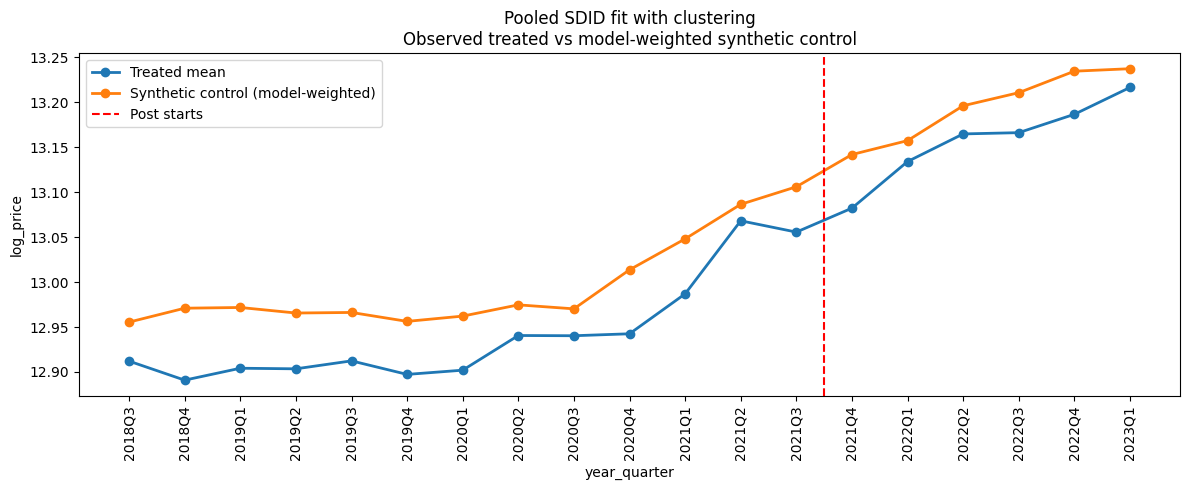

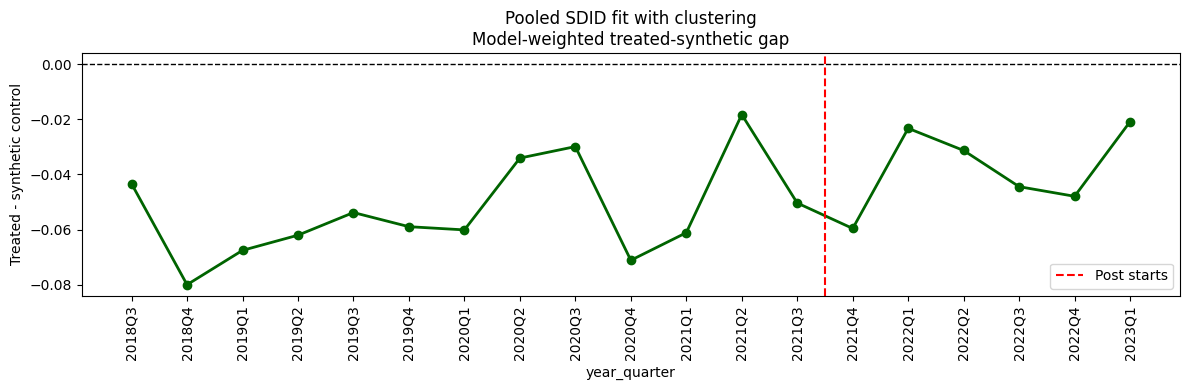

,year_quarter,treated_path,synthetic_path,gap
0,2018Q3,12.912070,12.955453,-0.043383
1,2018Q4,12.890931,12.970901,-0.079970
2,2019Q1,12.904177,12.971695,-0.067519
3,2019Q2,12.903524,12.965540,-0.062016
4,2019Q3,12.912364,12.966170,-0.053806
5,2019Q4,12.897322,12.956256,-0.058934
6,2020Q1,12.902012,12.962112,-0.060100
7,2020Q2,12.940554,12.974611,-0.034056
8,2020Q3,12.940296,12.970187,-0.029891
9,2020Q4,12.942464,13.013578,-0.071114


In [66]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_sdid_weighted_paths(
    panel_df,
    results,
    unit_col='unit_id',
    time_col='year_quarter',
    outcome_col='log_price',
    treated_col='treated',
    title='SyntheticDiD fit',
    normalize_within_period=True,
    add_intercept=True,
):
    # --- 1) unit weights from the fitted model ---
    control_weights = (
        pd.Series(results.unit_weights, name='weight')
        .rename_axis(unit_col)
        .reset_index()
    )

    # --- 2) treated path ---
    treated_path = (
        panel_df.loc[panel_df[treated_col] == 1]
        .groupby(time_col, sort=True)[outcome_col]
        .mean()
        .rename('treated_path')
    )

    # --- 3) weighted synthetic control path ---
    controls = (
        panel_df.loc[panel_df[treated_col] == 0, [unit_col, time_col, outcome_col]]
        .merge(control_weights, on=unit_col, how='inner')
        .copy()
    )

    if controls.empty:
        raise ValueError('No control units matched the SDID unit weights.')

    controls['weighted_outcome'] = controls[outcome_col] * controls['weight']

    synthetic_path = (
        controls.groupby(time_col, sort=True)
        .agg(
            weighted_outcome=('weighted_outcome', 'sum'),
            weight_sum=('weight', 'sum'),
        )
    )

    if normalize_within_period:
        # Good for unbalanced panels / missing control observations
        synthetic_path['synthetic_path'] = (
            synthetic_path['weighted_outcome'] / synthetic_path['weight_sum']
        )
    else:
        # Use raw weighted sum if you know weights already sum to 1
        synthetic_path['synthetic_path'] = synthetic_path['weighted_outcome']

    # --- 4) add SDID intercept/offset if present ---
    intercept = 0.0
    if add_intercept:
        for attr in ['intercept', 'alpha', 'bias', 'offset']:
            if hasattr(results, attr):
                intercept = getattr(results, attr)
                if intercept is not None:
                    break
        else:
            intercept = 0.0

    synthetic_path['synthetic_path'] = synthetic_path['synthetic_path'] + intercept

    # --- 5) combine for plotting ---
    plot_df = (
        pd.concat(
            [treated_path, synthetic_path['synthetic_path']],
            axis=1,
        )
        .reset_index()
        .sort_values(time_col)
        .reset_index(drop=True)
    )

    plot_df['gap'] = plot_df['treated_path'] - plot_df['synthetic_path']

    periods = plot_df[time_col].tolist()
    xpos = list(range(len(periods)))

    boundary_period = results.post_periods[0] if getattr(results, 'post_periods', None) else None
    boundary = periods.index(boundary_period) - 0.5 if boundary_period in periods else None

    # --- 6) main path plot ---
    plt.figure(figsize=(12, 5))
    plt.plot(xpos, plot_df['treated_path'], marker='o', linewidth=2, label='Treated mean')
    plt.plot(
        xpos,
        plot_df['synthetic_path'],
        marker='o',
        linewidth=2,
        label='Synthetic control (model-weighted)'
    )
    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, periods, rotation=90)
    plt.xlabel(time_col)
    plt.ylabel(outcome_col)
    plt.title(f'{title}\nObserved treated vs model-weighted synthetic control')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 7) gap plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(xpos, plot_df['gap'], marker='o', linewidth=2, color='darkgreen')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, periods, rotation=90)
    plt.xlabel(time_col)
    plt.ylabel('Treated - synthetic control')
    plt.title(f'{title}\nModel-weighted treated-synthetic gap')
    if boundary is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()

    return plot_df

plot_sdid_weighted_paths(
    panel_df=sdid_panel_pool,
    results=sdid_results_pool,
    unit_col='unit_id',
    time_col='year_quarter',
    outcome_col='log_price',
    treated_col='treated',
    title='Pooled SDID fit with clustering',
    normalize_within_period=True,
    add_intercept=True,
)

### Archived Clustering Grid-Search Helper

This final helper block was used to evaluate clustering parameter choices before the clustering path was retired.


In [83]:
# UNUSED: clustering-based SDID diagnostic retained only for reference.
# The pooled main specification in this notebook is the plain DiD workflow above.

from sklearn.cluster import DBSCAN
from diff_diff import SyntheticDiD
from diff_diff.prep import balance_panel
from shapely import wkt
import geopandas as gpd
import pandas as pd
import numpy as np
import warnings


def run_clustered_sdid_eval(
    base_df,
    cluster_eps_m,
    control_radius_m,
    min_treated_obs=10,
    min_control_obs=10,
    min_treated_units_per_period=1,
    min_control_units_per_period=1,
    variance_method='placebo',
    n_bootstrap=200,
    post_start='2021Q4',
):
    built = build_clustered_sdid_objects(
        base_df=base_df,
        cluster_eps_m=cluster_eps_m,
        control_radius_m=control_radius_m,
        min_treated_obs=min_treated_obs,
        min_control_obs=min_control_obs,
        min_treated_units_per_period=min_treated_units_per_period,
        min_control_units_per_period=min_control_units_per_period,
        post_start=post_start,
    )

    did_local = built['did_local']
    cluster_summary = built['cluster_summary']
    sdid_panel = built['sdid_panel']
    covariate_cols = built['covariate_cols']
    post_periods = built['post_periods']
    n_units_before_period_trim = built['n_units_before_period_trim']
    n_units_pre_balance = built['n_units_pre_balance']

    if did_local.empty and cluster_summary.empty:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'status': 'no_sample',
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    if did_local.empty or cluster_summary.empty:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'no_valid_clusters',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    if sdid_panel.empty:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'empty_after_balance',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': 0,
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    pre_periods = sorted(
        sdid_panel.loc[sdid_panel['year_quarter'] < post_start, 'year_quarter'].unique()
    )

    if len(post_periods) == 0 or len(pre_periods) == 0 or sdid_panel['treated'].nunique() < 2:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'invalid_post_or_treatment',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': sdid_panel['unit_id'].nunique(),
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    keep_covariates = [
        c for c in covariate_cols
        if c in sdid_panel.columns and sdid_panel[c].nunique(dropna=True) > 1
    ]

    try:
        sdid = SyntheticDiD(
            seed=42,
            variance_method=variance_method,
            n_bootstrap=n_bootstrap
        )

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter('always')
            res = sdid.fit(
                sdid_panel,
                outcome='log_price',
                treatment='treated',
                unit='unit_id',
                time='year_quarter',
                post_periods=post_periods,
                covariates=keep_covariates
            )

        treated_pre = sdid_panel[
            (sdid_panel['treated'] == 1) &
            (sdid_panel['year_quarter'].isin(pre_periods))
        ]['log_price']

        treated_pre_sd = treated_pre.std()
        pre_fit_rmse = res.pre_treatment_fit
        pre_fit_ratio = (
            pre_fit_rmse / treated_pre_sd
            if pd.notna(treated_pre_sd) and treated_pre_sd > 0
            else np.nan
        )
        poor_pre_fit = bool(pre_fit_ratio > 1) if pd.notna(pre_fit_ratio) else np.nan
        poor_pre_fit = poor_pre_fit or any(
            'Pre-treatment fit is poor' in str(w.message)
            for w in caught_warnings
        )

        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'ok',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'share_clusters_both_arms': cluster_summary['both_arms'].mean(),
            'median_treated_obs_per_cluster': cluster_summary['treated_obs'].median(),
            'median_control_obs_per_cluster': cluster_summary['control_obs'].median(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': sdid_panel['unit_id'].nunique(),
            'n_treated_units_post_balance': sdid_panel.loc[sdid_panel['treated'] == 1, 'unit_id'].nunique(),
            'n_control_units_post_balance': sdid_panel.loc[sdid_panel['treated'] == 0, 'unit_id'].nunique(),
            'att': res.att,
            'se': res.se,
            'p_value': res.p_value,
            'pre_fit_rmse': pre_fit_rmse,
            'poor_pre_fit': poor_pre_fit,
            'pre_fit_ratio': pre_fit_ratio,
            'n_covariates_kept': len(keep_covariates),
        }

    except Exception as e:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': f'error: {str(e)[:80]}',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': sdid_panel['unit_id'].nunique(),
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }


In [89]:
print(did_01x_new.loc[did_01x_new['treated'] == 1, 'delta_good_schools_0_1km'].value_counts(dropna=False))
print(did_01x_new.loc[did_01x_new['treated'] == 0, 'delta_good_schools_0_1km'].value_counts(dropna=False))

delta_good_schools_0_1km
1    2162
Name: count, dtype: int64
delta_good_schools_0_1km
0    43214
Name: count, dtype: int64
